In [38]:
#%config InlineBackend.figure_formats=['svg']
from src.Utils import plot_traces, save_results, get_means
from src.Dataset import dataset_TES
#from src.LoadAutoencoder import load_autoencoder
from src.ExistingAlgorithms import max_value, area, sklearn_available
from src.GaussianMixture import gaussian_mixture

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

import umap

import numpy as np
import matplotlib.pyplot as plt

In [39]:
def g2(photon_number):
   return 1 + (np.var(photon_number, axis=0) - np.mean(photon_number, axis=0)) / (np.mean(photon_number, axis=0)**2 + 1e-10)

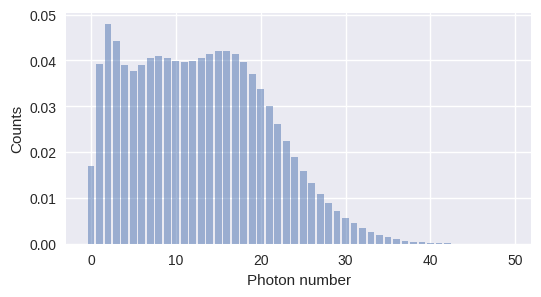

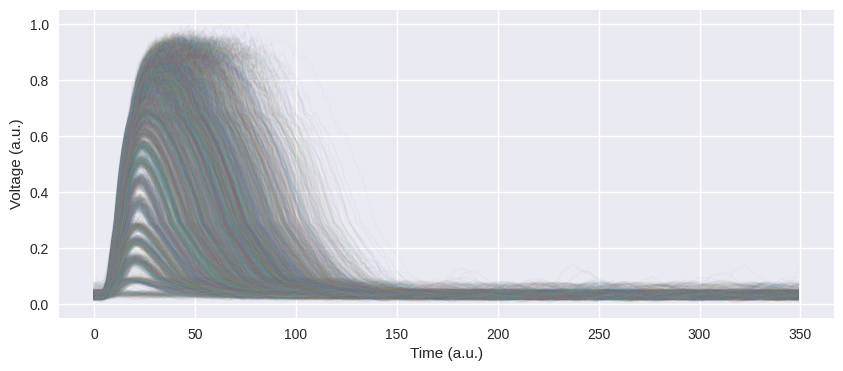

In [40]:
weights = [1.00000000e+00, 8.67567149e-01, 5.11893733e-01, 4.64791825e-01, 
           1.95257413e-01, 3.48166360e-01,1.24623185e-13, 3.89968505e-14, 3.60043421e-01]

#weights = [0.00047741680462955936, 0.0004709397517675953, 0.0010445432139792974, 0.002944736179232991, 0.04200636206501693, 0.0678533708472783, 0.27526434576344766, 0.1658809085942664, 0.5344563925233353, 0.4171218544172766, 1.083876657430484e-16, 0.2504288272925047, 0.9999999999999999]

weights = [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 
           5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 
           0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]

path_save = 'src/Results TES (Uniform)/Low Dimension'
path_results = 'src/Results TES (Uniform)'

data_train, data_test, expected_prob = dataset_TES(weights = weights,
                                                signal_size = 8192,
                                                interval = [0,350],#270],
                                                order_dB = False,
                                                normalize = True,
                                                plot_expected = True,
                                                plot_traces = True,
                                                n_photon_number = 50)

### Parametric t-SNE

In [41]:
import torch
from src.ParametricTSNE.train import load_model
from src.ParametricTSNE.model import Network

model = load_model(Network, f'src/Models/Sweep 1D/test 15').to(device='cpu')

data_test_ = torch.from_numpy(data_test).float().view(-1, 350).to(device='cpu')
data_test_ = (data_test_ - data_test_.min()) / (data_test_.max() - data_test_.min())


with torch.no_grad():
    X_l_PTSNE = model(data_test_, encode = True).cpu().numpy()

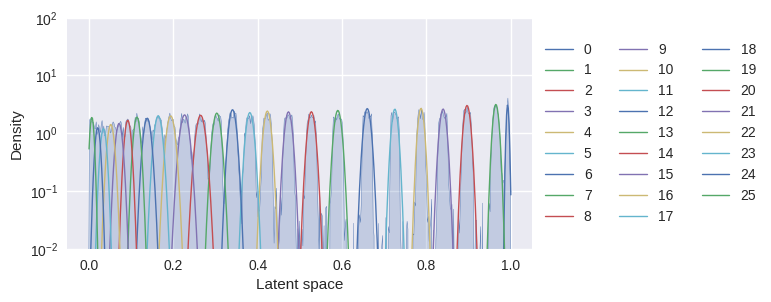

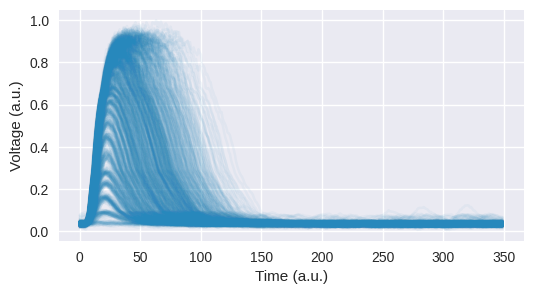

/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


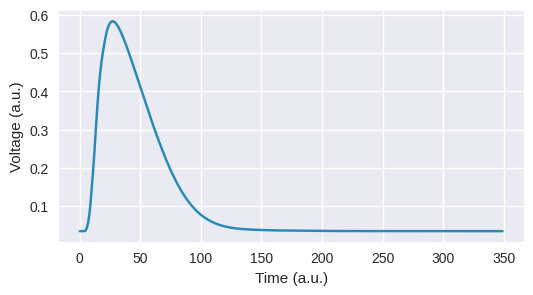

In [42]:
name_method = 'PTSNE 1D'
gm = gaussian_mixture(X_low = X_l_PTSNE,
                      X_high = data_test,
                      number_cluster = 26, 
                      cluster_iter = 5,
                      means_init = get_means(name_method, path = path_results),
                      tol = 1e-3,
                      info_sweep = 0,
                      plot_sweep = True )

gm.plot_density(bw_adjust = 0.01)
# gm.plot_cluster(plot_kde = False, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

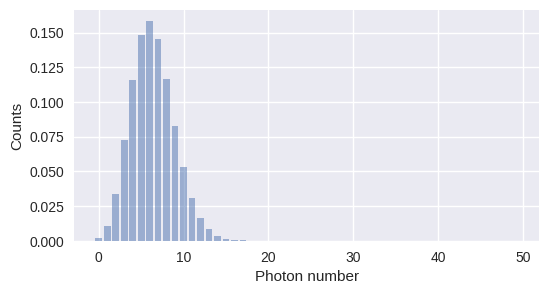

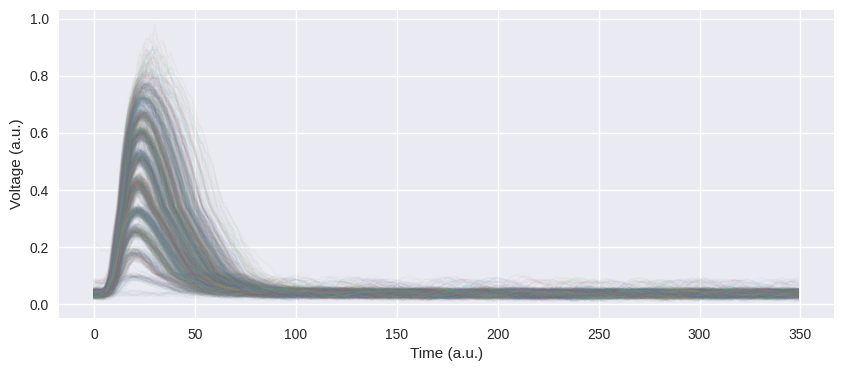

In [33]:
weights = [1,0,0,0]

path_save = 'src/Results TES (Uniform)/Low Dimension'
path_results = 'src/Results TES (Uniform)'

data_train_1, data_test_1, expected_prob_1,  = dataset_TES(weights = weights,
                                                path_random_index=None,
                                                signal_size = 8192,
                                                interval = [0,350],#270],
                                                order_dB = False,
                                                normalize = True,
                                                plot_expected = True,
                                                plot_traces = True,
                                                n_photon_number = 50,
                                                return_db=True)

1.0229924327690965


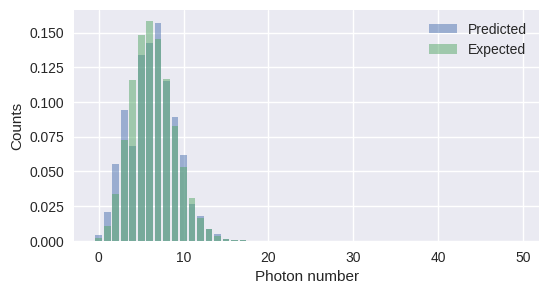

In [37]:
data_test_1_ = torch.from_numpy(data_test_1).float().view(-1, 350).to(device='cpu')
data_test_1_ = (data_test_1_ - data_test_1_.min()) / (data_test_1_.max() - data_test_1_.min())

X_l_PTSNE_1 = model(data_test_1_, encode = True).cpu().detach().numpy()

label = gm.predict(X_l_PTSNE_1)
n_arr = np.arange(expected_prob_1.shape[0])
predicted_prob_1, _ = np.histogram(label, n_arr)
predicted_prob_1 = predicted_prob_1 / predicted_prob_1.sum()

print(g2(label))

with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize=(6,3), dpi=100)
    plt.bar(x = n_arr[:-1], 
                height = predicted_prob_1,
                alpha = 0.5,
                label='Predicted')
    plt.bar(x = n_arr, 
                height = expected_prob_1,
                alpha = 0.5,
                label='Expected')
    plt.legend()
    plt.ylabel('Counts')
    plt.xlabel('Photon number')
    plt.show()